In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow import keras
from tensorflow.keras import layers

In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv("airline_passengers.csv")

# Ensure 'Passengers' column exists and rename if necessary
if "Passengers" not in df.columns:
    # Assuming the second column (index 1) contains passenger data
    # and might be unnamed or named differently.
    original_second_col_name = df.columns[1]
    df = df.rename(columns={original_second_col_name: "Passengers"})

# Remove rows with NaN values in the 'Passengers' column AFTER potential renaming
# This handles the footer row in the CSV which contains NaN
df.dropna(subset=['Passengers'], inplace=True)

# Select passenger column
data = df["Passengers"].values.reshape(-1, 1)

# Display first 5 rows
print(df.head())

     Month  Passengers
0  1949-01       112.0
1  1949-02       118.0
2  1949-03       132.0
3  1949-04       129.0
4  1949-05       121.0


In [11]:
# Scale values between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [12]:
def create_dataset(dataset, lookback=12):
    X = []
    y = []

    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback, 0])
        y.append(dataset[i + lookback, 0])

    return np.array(X), np.array(y)


LOOKBACK = 12

X, y = create_dataset(scaled_data, LOOKBACK)

print(X.shape)
print(y.shape)

(132, 12)
(132,)


In [13]:
# 80% Training and 20% Testing
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (105, 12, 1)
Testing Set : (27, 12, 1)


In [14]:
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),

    layers.LSTM(
        50,
        activation="relu",
        return_sequences=True
    ),

    layers.LSTM(
        50,
        activation="relu"
    ),

    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=100,
    batch_size=8,
    verbose=0
)

In [16]:
# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Convert predictions back to original scale
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

# Original values
y_train_actual = scaler.inverse_transform(
    y_train.reshape(-1, 1)
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

# RMSE Calculation
train_rmse = np.sqrt(
    mean_squared_error(y_train_actual, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test_actual, test_pred)
)

print("Train RMSE :", round(train_rmse, 2))
print("Test RMSE :", round(test_rmse, 2))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Train RMSE : 14.87
Test RMSE : 38.46


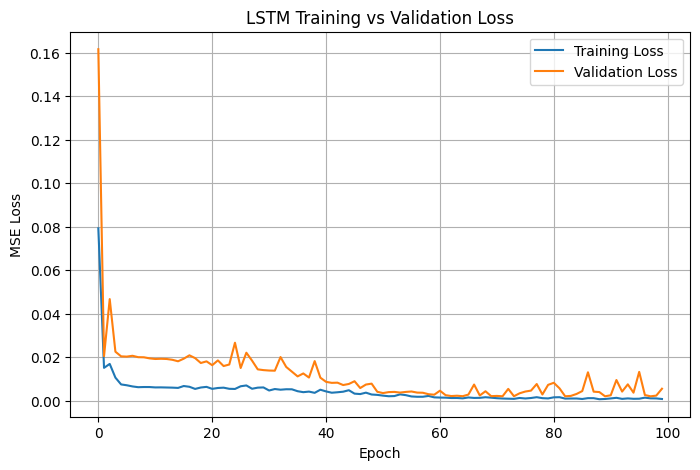

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

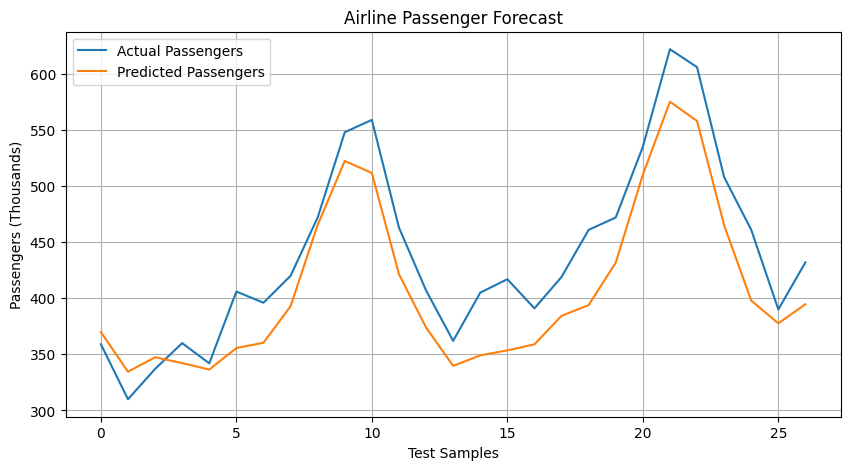

In [18]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test_actual,
    label="Actual Passengers"
)

plt.plot(
    test_pred,
    label="Predicted Passengers"
)

plt.title("Airline Passenger Forecast")
plt.xlabel("Test Samples")
plt.ylabel("Passengers (Thousands)")

plt.legend()
plt.grid(True)

plt.show()